# WM-811K 분할 전 EDA

canonical 구조·품질을 로컬에서 확인합니다. 원본 pickle, 라벨 수정, 충돌 제외, 분할, resize, 증강, 모델 학습은 실행하지 않습니다.

노트북·CLI·향후 에이전트는 `src/wafer_dl/eda.py`의 같은 코어를 사용합니다. 현재 에이전트 실행기·LLM 연결은 미구현이며 EDA 코어만 호출 가능한 상태입니다.

**출력에는 실제 집계·이미지가 포함됩니다. LLM·외부 추적에 보내지 말고 Git 공유 전 모든 셀 출력을 지우세요.** 전체 데이터 EDA는 구조·품질 확인용입니다. 입력 해상도·증강 선택은 분할 후 Train/Validation에서 진행합니다.

먼저 canonical 정합성 검사를 통과한 묶음을 사용하세요. EDA는 전체 NPZ 정합성 검사를 대신하지 않습니다.

In [1]:
# ==========================================
# 노트북 실행 위치와 무관하게 프로젝트 루트 확인
# - 작업 폴더는 변경하지 않고 import 경로만 추가
# - 코어는 원본 pickle을 읽지 않음
# ==========================================
from pathlib import Path
import sys
import json

project_root = next((p for p in (Path.cwd(), *Path.cwd().parents)
                     if (p / 'src/wafer_dl/eda.py').is_file()), None)
if project_root is None:
    raise RuntimeError('프로젝트 내부에서 노트북을 실행하세요.')
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from IPython.display import display
import matplotlib.pyplot as plt
from src.wafer_dl.eda import (
    load_eda_metadata, summarize_metadata, select_example_positions,
    load_example_maps, plot_distributions, plot_die_statistics, plot_examples, run_eda,
)
print('공통 EDA 코어 준비 완료. 아직 데이터를 읽지 않았습니다.')

공통 EDA 코어 준비 완료. 아직 데이터를 읽지 않았습니다.


## 1. 새 canonical 묶음 선택

`CANONICAL_DIR`에 실제 폴더 경로를 입력할 수 있습니다. `None`이면 수정 라벨 버전의 후보가 하나일 때만 자동 선택합니다. 여러 후보에서 최신 폴더를 임의로 선택하지 않습니다.

In [2]:
# 실제 폴더를 직접 선택하려면 None 대신 경로 문자열을 넣으세요.
CANONICAL_DIR = None

if CANONICAL_DIR is None:
    base = project_root / 'data/processed/wm811k/canonical'
    candidates = []
    from src.wafer_dl.validate_canonical import read_json
    for folder in sorted(base.glob('canonical_*')):
        if folder.is_dir() and (folder / 'SUCCESS.json').is_file():
            if read_json(folder / 'conversion.json').get('label_normalization_version') == 'wm_label_v2':
                candidates.append(folder)
    if len(candidates) != 1:
        print('수정 버전 후보 폴더:', [p.name for p in candidates])
        raise ValueError('후보가 하나가 아닙니다. CANONICAL_DIR에 실제 폴더를 지정하세요.')
    canonical_dir = candidates[0]
else:
    canonical_dir = Path(CANONICAL_DIR)
    if not canonical_dir.is_absolute():
        canonical_dir = project_root / canonical_dir

metadata = load_eda_metadata(canonical_dir)
tables = summarize_metadata(metadata)
print('metadata 집계 완료. 맵 배열은 아직 읽지 않았습니다.')

metadata 집계 완료. 맵 배열은 아직 읽지 않았습니다.


## 2. 클래스·미라벨·격리·중복 요약

- `labeled_samples`와 `accepted_labeled_samples`를 구분합니다. 
- 미라벨은 정상 `None`으로 취급하지 않습니다. 
- 같은 맵 내용의 중복은 같은 실물 웨이퍼의 복제라고 단정할 수 없습니다. 
- Lot 수는 독립 연결 그룹 수와 다릅니다. 
- 연결 그룹 상세 진단은 `diagnose_split` 보고서를 함께 보세요.

In [3]:
display(tables['classes'])
display(tables['statuses'])
display(tables['statistics'])
display(tables['shapes'].head(20))
display(tables['lot_sizes'].describe())

,labeled_samples,accepted_labeled_samples,accepted_lot_count
pattern_label,,,
None,147431,147431,6591
Center,4294,4294,1648
Donut,555,555,233
Edge-Loc,5189,5189,3211
Edge-Ring,9680,9680,1075
Loc,3593,3593,2472
Near-Full,149,149,137
Random,866,866,449
Scratch,1193,1193,1059


,,rows
label_status,quality_status,
labeled,accepted,172950
unlabeled,accepted,638507


{'row_count': 811457,
 'rows_with_valid_map': 811457,
 'lot_count': 46293,
 'duplicate_map_groups': 32630,
 'rows_in_duplicate_groups': 147488,
 'map_label_conflict_groups': 14,
 'split_complete': False,
 'training_ready': False}

,map_height,map_width,rows
88,32,29,108687
34,25,27,64083
255,49,39,39323
38,26,26,30078
77,30,34,29513
102,33,33,23886
98,33,29,20276
162,39,37,15327
292,52,59,14812
84,31,31,14569


count    46293.000000
mean        17.528719
std          8.964477
min          1.000000
25%         10.000000
50%         24.000000
75%         25.000000
max         25.000000
Name: rows_per_lot, dtype: float64

## 3. 분포 그림

- 클래스·상태 건수는 로그축으로 다수/희소 그룹을 함께 확인합니다. 
- 맵 크기·종횡비는 resize 전 구조입니다. 
- 불량 다이 비율은 유효 다이 중 값 2의 비율이며 SECOM 불량 확률과 다릅니다.

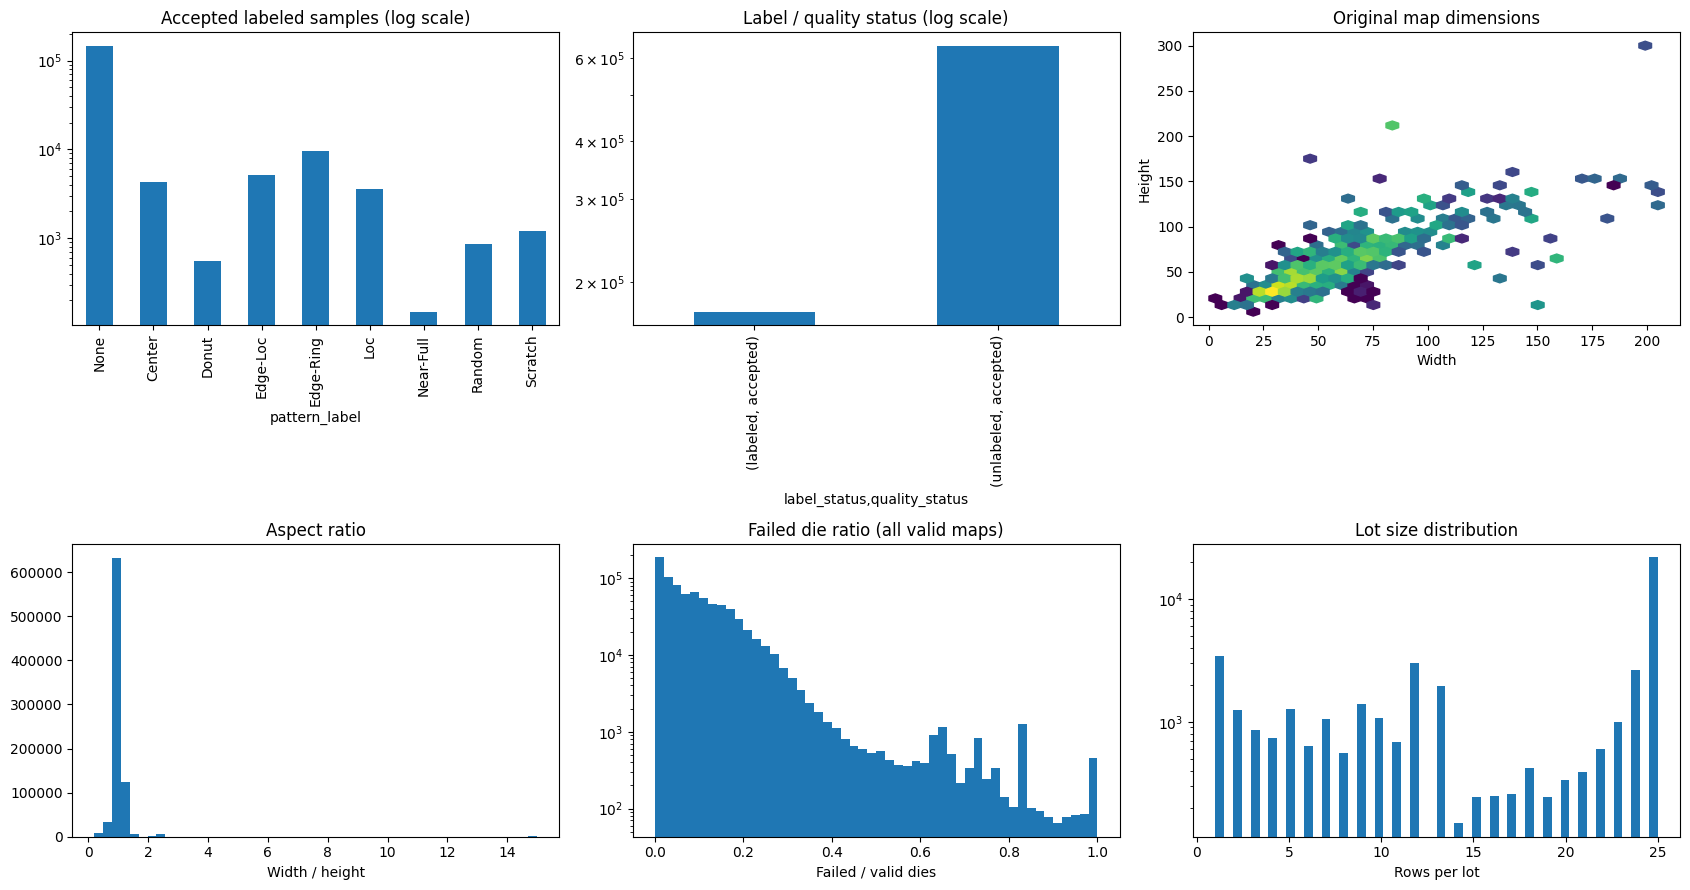

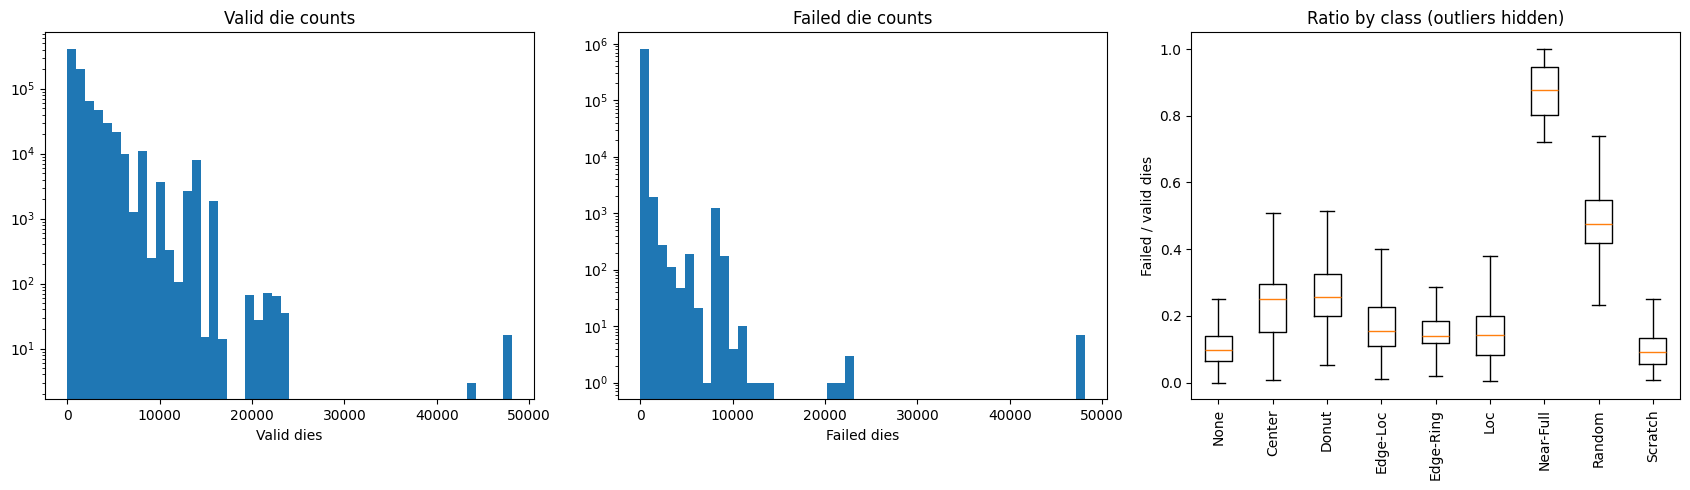

In [4]:
figure = plot_distributions(metadata, tables)
plt.show()
plt.close(figure)
figure = plot_die_statistics(metadata)
plt.show()
plt.close(figure)

## 4. 수치 metadata 상관분석

- accepted 유효 맵의 완전 관측 행(미라벨 포함)으로 Spearman·Pearson을 비교합니다. 
- 클래스 번호·Lot·해시·행 번호는 제외합니다.
- 상수 열·3건 미만은 N/A입니다. 
- 전체 계수는 클래스 구성·중복·Lot의 영향을 받으며 독립 표본 검정이 아닙니다.
- 불량 비율=불량 다이 수/유효 다이 수이므로 계산상 연관에 주의하세요. 
- 상관은 인과관계나 자동 특징 선택 근거가 아닙니다. 모델용 선택은 분할 후 Train에서 검토합니다.
- 산점도만 최대 5,000건을 고정 추출하며 클래스 균형 표본이 아닙니다. 
- 표·그림은 로컬 전용입니다.

,rows
all_accepted,811457


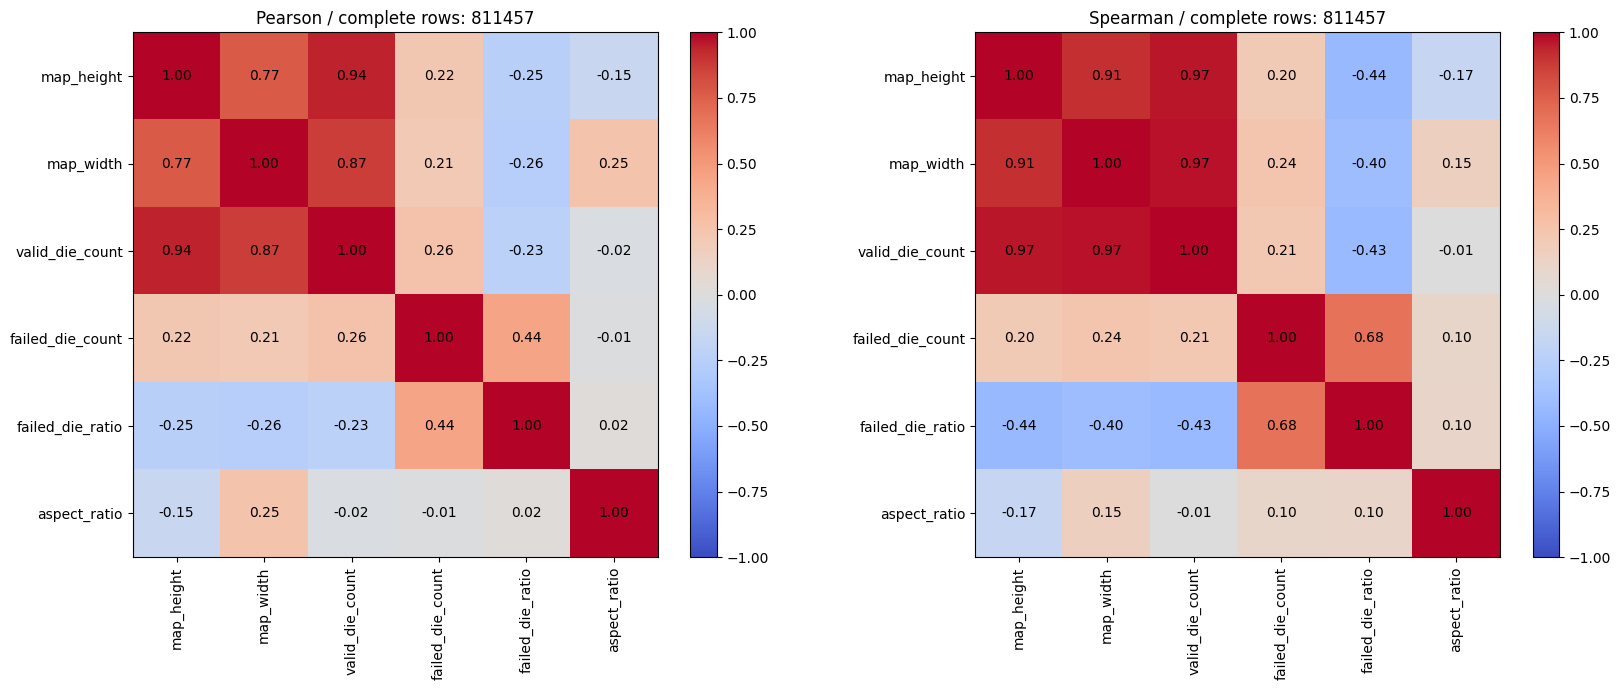

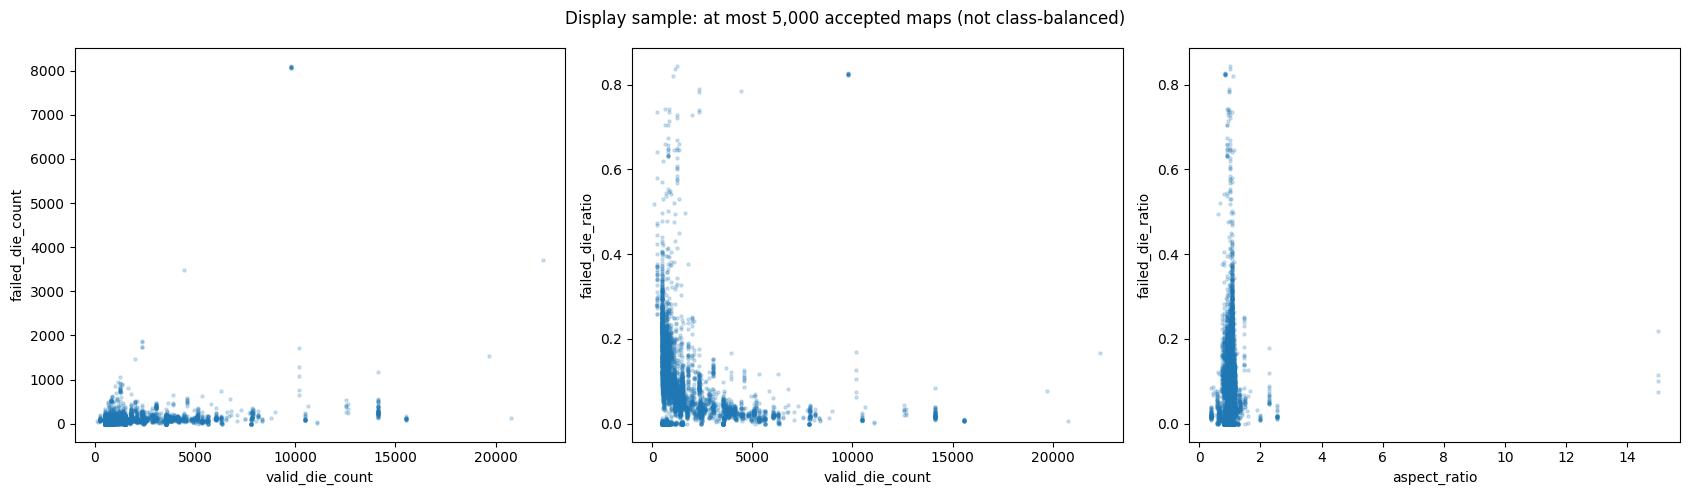

,pattern_label,method,first,second,rows,correlation
10,None,pearson,valid_die_count,failed_die_ratio,147431,-0.444934
25,None,spearman,valid_die_count,failed_die_ratio,147431,-0.703998
40,Center,pearson,valid_die_count,failed_die_ratio,4294,-0.389056
55,Center,spearman,valid_die_count,failed_die_ratio,4294,-0.596383
70,Donut,pearson,valid_die_count,failed_die_ratio,555,0.224154
85,Donut,spearman,valid_die_count,failed_die_ratio,555,0.127126
100,Edge-Loc,pearson,valid_die_count,failed_die_ratio,5189,-0.278933
115,Edge-Loc,spearman,valid_die_count,failed_die_ratio,5189,-0.517977
130,Edge-Ring,pearson,valid_die_count,failed_die_ratio,9680,-0.631286
145,Edge-Ring,spearman,valid_die_count,failed_die_ratio,9680,-0.770132


In [5]:
from src.wafer_dl.eda import summarize_correlations, plot_correlations, plot_correlation_scatter

# 전체 적격 행의 계수와 클래스별 표본 수를 확인합니다.
correlations = summarize_correlations(metadata)
display(correlations['support'])
figure = plot_correlations(correlations)
plt.show()
plt.close(figure)
figure = plot_correlation_scatter(metadata)
plt.show()
plt.close(figure)
# 우선 유효 다이 수와 불량 비율의 관계를 클래스별로 비교합니다.
class_correlations = correlations['by_class']
display(class_correlations.loc[
    class_correlations['first'].eq('valid_die_count') &
    class_correlations['second'].eq('failed_die_ratio')
])

## 5. 클래스별 원본 크기 예시

- 회색=웨이퍼 밖(0), 초록=정상 다이(1), 빨강=불량 다이(2). 
- 클래스별 첫 유효 1건만 확인하며 대표성이나 클래스 전체 특성을 보장하지 않습니다. 
- 이 셀만 소수의 NPZ 배열을 숫자 전용으로 읽습니다. 
- 예시를 보고 Test용 변환 설정을 최적화하지 않습니다.

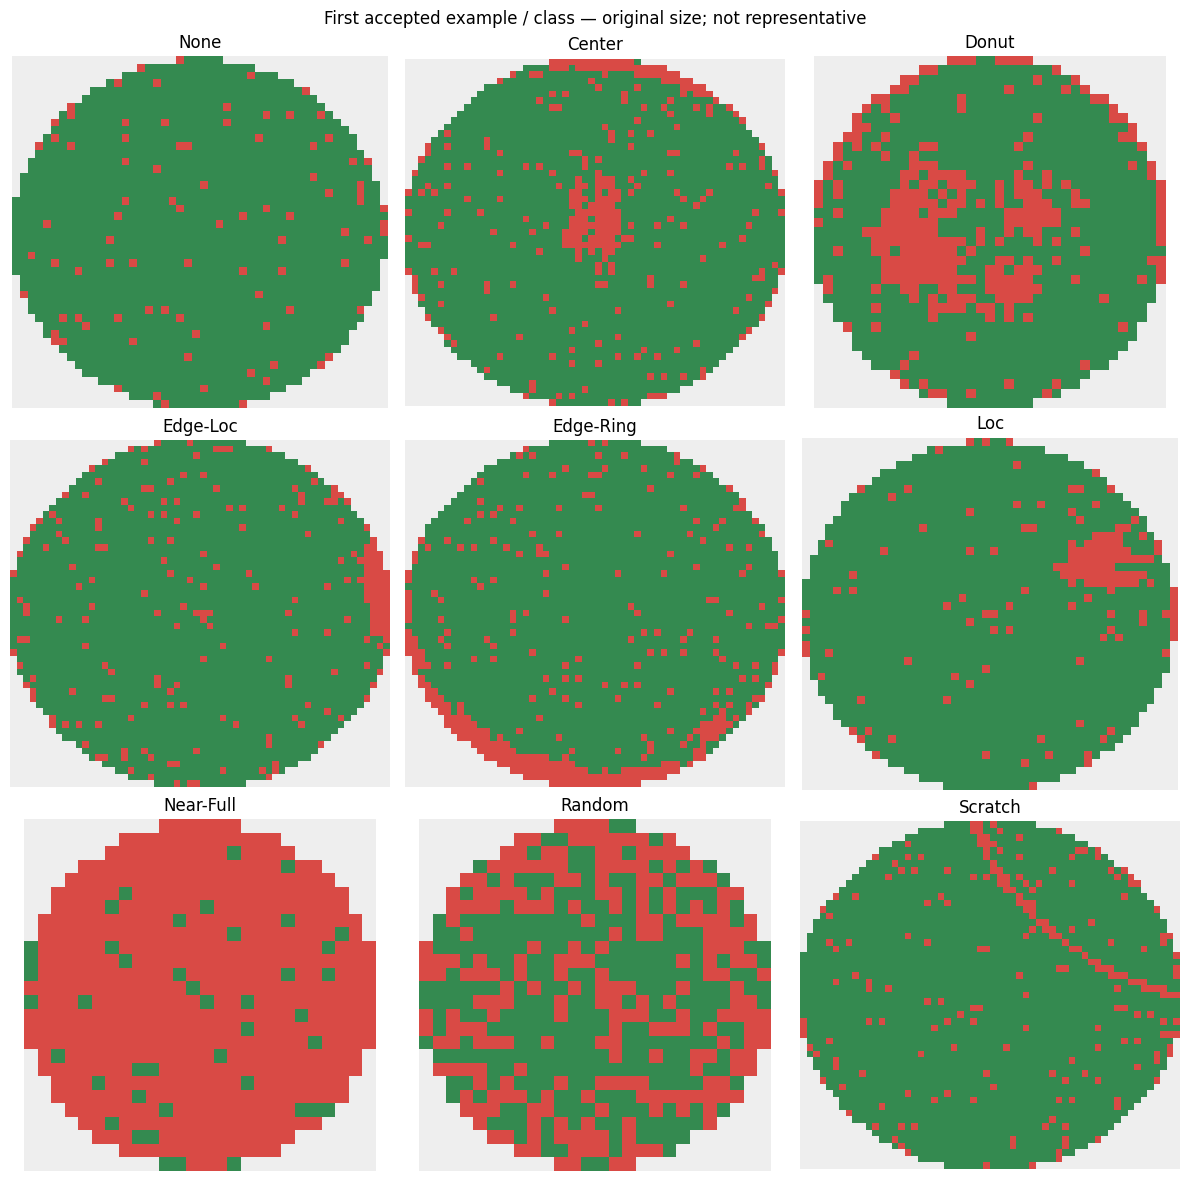

In [6]:
positions = select_example_positions(metadata)
examples = load_example_maps(canonical_dir, positions)
figure = plot_examples(examples)
plt.show()
plt.close(figure)

## 6. 로컬 보고서 저장 — 선택 실행

- `SAVE_REPORT=True`로 바꾸면 에이전트가 호출할 때와 동일한 `run_eda()`로 재집계·저장합니다. 
- 기존 폴더를 덮어쓰지 않으므로 실행마다 새 이름을 지정하세요. 
- 반환 상태는 로컬 실행용이며 현재 LLM 상태 계약에 자동 전달하지 않습니다.

In [7]:
SAVE_REPORT = False
OUTPUT_DIR = project_root / 'reports/wm811k/figures/eda_01'
if SAVE_REPORT:
    result = run_eda(canonical_dir, OUTPUT_DIR)
    print(result['status'])
else:
    print('보고서를 저장하지 않았습니다.')

보고서를 저장하지 않았습니다.


## 7. 로컬 검토 메모

- [ ] 9개 클래스가 존재하고 미라벨·격리와 구분되는지 확인
- [ ] 맵 크기·종횡비·다이 수의 극단값과 원본 패턴 확인
- [ ] 클래스별 불량 비율 차이와 희소 클래스 지원 확인
- [ ] 중복·라벨 충돌 제외 영향 진단 보고서 확인
- [ ] 제외 정책 승인 후 Lot·동일 맵 비중첩 분할로 진행

이 절은 분할 전 EDA 검토 메모입니다.

## 8. 입력 변환 검증 결과

먼저 `python -m src.wafer_dl.check_transform --split-dir data/splits/wm811k/group_v1 --config configs/wm811k/transform.json --output-dir reports/wm811k/transform_v1`을 프로젝트 루트에서 직접 실행합니다. 아래 셀은 저장된 결과만 읽습니다.
불량·유효 영역 전체 소실이 없어도 Scratch 선이나 고리 모양이 보존되었는지 직접 비교하세요. 첫 사례와 극단 사례만 표시하며 Test 맵은 포함하지 않습니다. 비율 차이 0.01은 1%p입니다.
결과·그림은 로컬 전용이며 커밋 전에 출력 정보를 점검하세요.

검사 상태: transform_check_passed
형태 보존 시각 검토는 별도로 필요합니다. 학습 준비 완료가 아닙니다.


,split,class,rows,failed_region_lost,valid_region_lost,max_absolute_ratio_delta,mean_absolute_ratio_delta,ratio_comparison_rows
0,train,Center,3144,0,0,0.010180,0.001959,3144
1,train,Donut,439,0,0,0.008228,0.001759,439
2,train,Edge-Loc,3653,0,0,0.012253,0.001480,3653
3,train,Edge-Ring,7685,0,0,0.014667,0.001241,7685
4,train,Loc,2811,0,0,0.008353,0.001406,2811
5,train,Near-Full,113,0,0,0.006891,0.001192,113
6,train,None,101768,0,0,0.012443,0.001266,101768
7,train,Random,688,0,0,0.016231,0.002110,688
8,train,Scratch,960,0,0,0.012648,0.001291,960
9,validation,Center,573,0,0,0.008512,0.001733,573


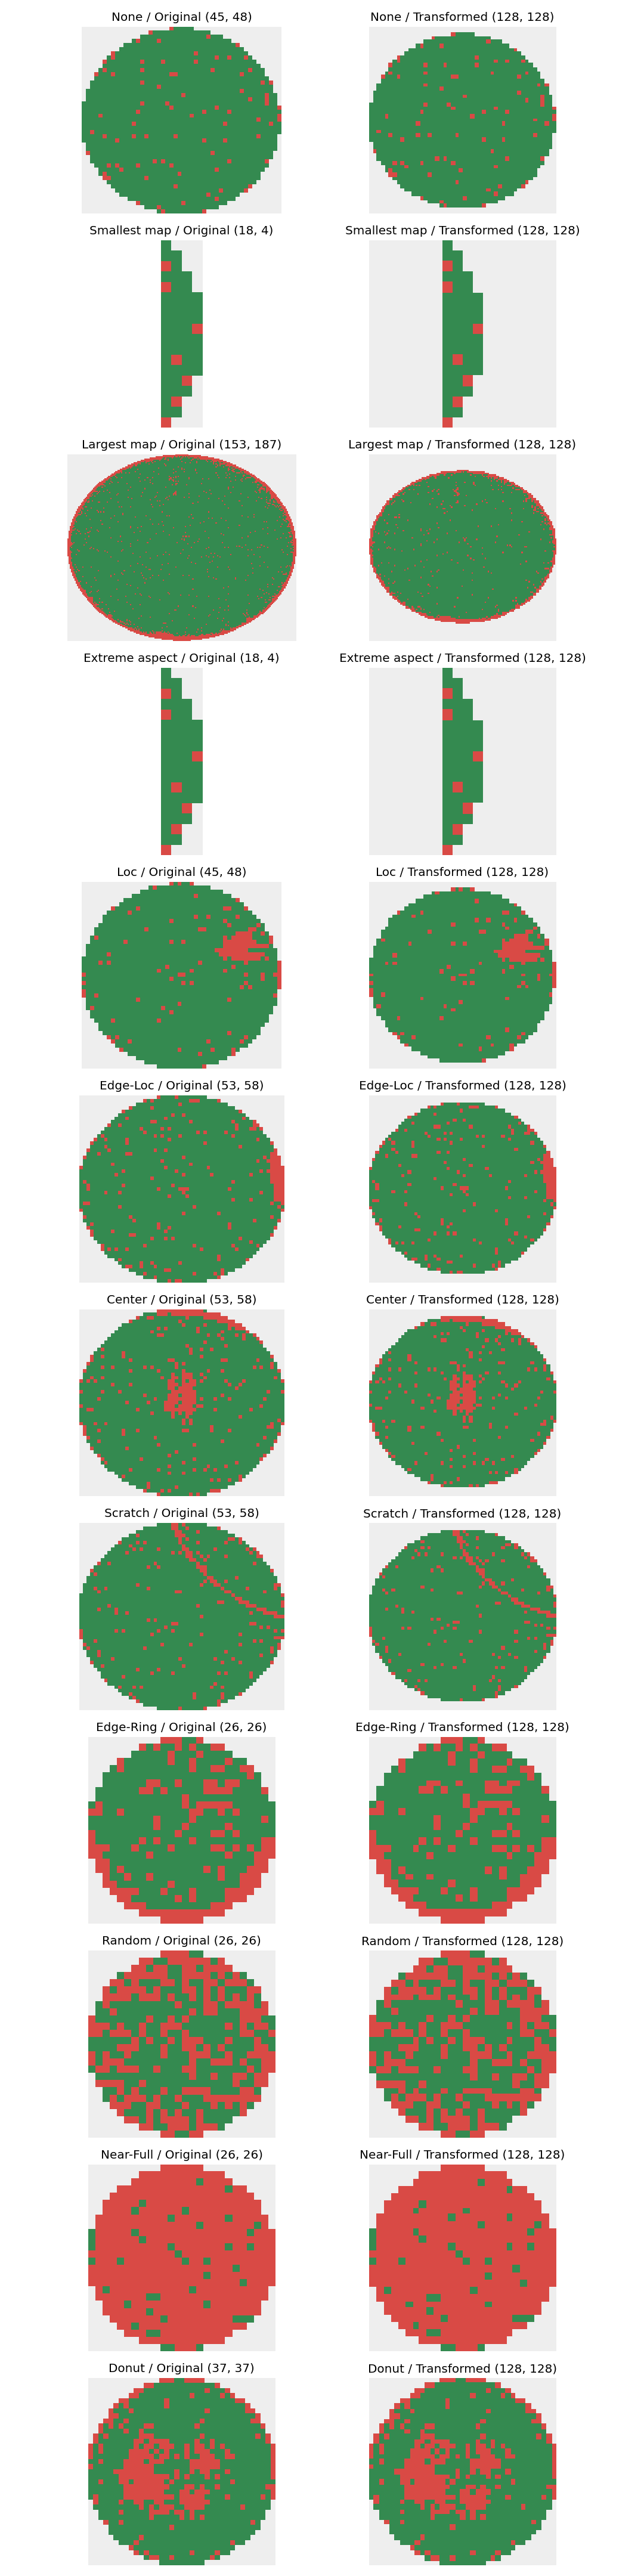

In [8]:
import pandas as pd
from IPython.display import Image, display
from src.wafer_dl.validate_canonical import read_json

# 실제 변환 검사는 별도 실행하고 여기서는 저장 완료된 결과만 확인합니다.
TRANSFORM_CHECK_DIR = project_root / 'reports/wm811k/transform_v1'
if (TRANSFORM_CHECK_DIR / 'SUCCESS.json').is_file():
    completion = read_json(TRANSFORM_CHECK_DIR / 'SUCCESS.json')
    if completion.get('status') != 'transform_check_complete':
        raise ValueError('변환 검사 완료 표식이 아닙니다.')
    transform_report = read_json(TRANSFORM_CHECK_DIR / 'transform_check.json')
    print('검사 상태:', transform_report['status'])
    print('형태 보존 시각 검토는 별도로 필요합니다. 학습 준비 완료가 아닙니다.')
    display(pd.DataFrame(transform_report['classes']))
    display(Image(filename=str(TRANSFORM_CHECK_DIR / 'examples.png')))
else:
    print('저장된 변환 검사 결과가 없습니다. 안내된 명령을 먼저 실행하세요.')

## 9. 실제 전처리·그룹 분할·캐시 결과

1~7절의 EDA는 충돌 제외 전입니다. 이후 실제 분할에서 라벨 충돌 14그룹의 33행(라벨 28·미라벨 5)을 제외했고, 지도학습 대상은 172,922건입니다. 원본 삭제나 임의 재라벨링은 하지 않았습니다.
`split_summary.csv`는 집계표이고 `split_manifest.jsonl`의 `split_group_id`는 연결 그룹, `group_split`은 그룹 배정, `split`은 각 행의 최종 용도입니다. 같은 Lot·동일 맵 관계를 유지하며 약 70/15/15로 나눴습니다.
아래 셀은 저장된 JSON 요약만 읽습니다. 원본 pickle·NPZ·캐시 배열·개별 색인을 읽거나 재분할·캐시 생성·모델 학습을 실행하지 않습니다. Test 클래스 집계는 이미 확정한 분할의 구조 확인이며 Test 예측 성능 평가가 아닙니다.
프로젝트 루트 설정 셀을 먼저 실행하세요. 상세 해석은 [report.md 10~14절](report.md#10-실제-전처리-실행과-데이터-수-변화)을 참고하세요.

In [9]:
import pandas as pd
from IPython.display import display
from src.wafer_dl.validate_canonical import read_json

# ==========================================
# 저장된 분할·캐시 요약만 확인
# - 완료 표식과 분할 프로토콜의 정합성을 확인
# - 숫자 배열이나 Test 이미지를 열지 않고 집계를 표시
# ==========================================
SPLIT_RESULT_DIR = project_root / 'data/splits/wm811k/group_v1'
CACHE_RESULT_DIR = project_root / 'data/processed/wm811k/input_cache/wm_resize_v1'
required_summaries = [SPLIT_RESULT_DIR / 'SUCCESS.json', SPLIT_RESULT_DIR / 'split.json',
                      CACHE_RESULT_DIR / 'SUCCESS.json', CACHE_RESULT_DIR / 'cache.json']
if all(path.is_file() for path in required_summaries):
    split_summary = read_json(SPLIT_RESULT_DIR / 'split.json')
    split_completion = read_json(SPLIT_RESULT_DIR / 'SUCCESS.json')
    cache_summary = read_json(CACHE_RESULT_DIR / 'cache.json')
    cache_completion = read_json(CACHE_RESULT_DIR / 'SUCCESS.json')
    protocol = split_summary.get('split_protocol_id')
    if not (split_summary.get('status') == split_completion.get('status') == 'split_complete'
            and cache_summary.get('status') == cache_completion.get('status') == 'cache_complete'
            and protocol is not None
            and all(item.get('split_protocol_id') == protocol
                    for item in (split_completion, cache_summary, cache_completion))):
        raise ValueError('완료 상태 또는 분할 프로토콜이 일치하지 않습니다. 결과 묶음을 확인하세요.')

    # 고정 클래스 번호 순서로 집계하며 캐시도 같은 매핑인지 확인합니다.
    mapping = split_summary['class_mapping']
    if mapping != cache_summary['class_mapping']:
        raise ValueError('분할과 캐시의 클래스 매핑이 다릅니다.')
    split_table = pd.DataFrame(
        {name: split_summary['class_counts'][name] for name in ('train', 'validation', 'test')},
        index=[mapping[str(index)] for index in range(9)],
    )
    split_table.index.name = '클래스'
    display(split_table)
    split_totals = split_table.sum()
    display(pd.DataFrame({'표본 수': split_totals,
                          '전체 라벨 대상 비율(%)': split_totals / split_totals.sum() * 100}))
    print('충돌 그룹:', split_summary['excluded_conflict_groups'],
          '/ 제외 행:', split_summary['excluded_rows'])
    print('그룹 비중첩 검사:', split_summary['overlap_check_passed'])

    # 준비된 캐시만 표시합니다. Test 분할과 Test 캐시 존재는 별개입니다.
    cache_rows = [{'구간': name, '표본 수': item['rows'], 'shard 수': len(item['shards'])}
                  for name, item in cache_summary['splits'].items()]
    display(pd.DataFrame(cache_rows))
    print('캐시 생성 시 Test 맵 접근:', cache_summary['test_maps_read'])
    print('이번 셀은 저장 집계만 읽었습니다. 배열 무결성 재검사나 첫 배치 재실행이 아닙니다.')
else:
    print('완료된 분할·캐시 요약이 없습니다. 로컬 결과 폴더를 연결하세요. 자동 생성하지 않습니다.')

,train,validation,test
클래스,,,
None,101768,22821,22831
Center,3144,573,574
Donut,439,58,58
Edge-Loc,3653,764,763
Edge-Ring,7685,997,996
Loc,2811,390,389
Near-Full,113,18,18
Random,688,89,89
Scratch,960,117,116


,표본 수,전체 라벨 대상 비율(%)
train,121261,70.124680
validation,25827,14.935636
test,25834,14.939684


충돌 그룹: 14 / 제외 행: 33
그룹 비중첩 검사: True


,구간,표본 수,shard 수
0,train,121261,30
1,validation,25827,7


캐시 생성 시 Test 맵 접근: False
이번 셀은 저장 집계만 읽었습니다. 배열 무결성 재검사나 첫 배치 재실행이 아닙니다.


## 10. 입력 계약 확인 기록과 데이터 전달

2026-10-10 사용자가 공유한 CLI 출력 기준으로 Train·Validation 모두 `dataset_batch_passed`입니다. 아래는 실행 이력이며 노트북 셀 실행으로 새로 검증한 결과는 아닙니다.

| 구간 | 이미지 형태 | 이미지 dtype | 라벨 dtype | Test 맵 접근 |
| --- | --- | --- | --- | --- |
| Train | `[32,2,128,128]` | `torch.float32` | `torch.int64` | 없음 |
| Validation | `[32,2,128,128]` | `torch.float32` | `torch.int64` | 없음 |

- 채널 순서는 불량 마스크(`map==2`)·유효 다이 마스크(`map>0`)입니다. 라벨 0~8은 픽셀 상태 0·1·2와 별개입니다.
- 147,088건 변환 검사에서 불량·유효 영역 전체 소실은 0건이었습니다. 이것이 모든 얇은 선·고리 형태의 동등성을 증명하지는 않습니다.
- 첫 배치 통과는 전체 Epoch·다중 worker 처리량·모델 성능 확인이 아닙니다. 캐시의 `training_ready=false`도 자동 변경되지 않습니다.
- Test 25,834건은 분할 완료 상태이고 캐시는 미준비입니다. 고정 규칙으로 준비하는 것 자체는 모델 평가가 아니며, Test 결과로 전처리·모델을 반복 조정하지 않습니다.
- 캐시 전체(완료 표식·요약·색인·NPY 포함)는 Git 밖에서 전달합니다. 데이터를 받은 환경에서 첫 배치 명령을 다시 확인하며 재분할하지 않습니다.
- 명령과 학습 연결 예시는 [캐시·Dataset 사용법](../../docs/WM811K/CACHE_DATASET.md)을 참고하세요. 실제 코드·설정은 Git으로 공유합니다.
- 전체 EDA에는 분할 전 표본을 사용했습니다.
- 위 상세 집계·표본·그림·경로는 향후 에이전트의 외부 LLM·추적 서비스에 자동 전달하지 않습니다. 노트북 공개 전에는 기존 출력의 데이터 노출도 별도로 점검하세요.